# Riset Strategi — Mencari Pengganti Entry V5 (1 posisi, spot, long-only)

**Latar belakang**: notebook 06 membuktikan strategi V5 (beli bottoming saat pasar panik) **rugi
out-of-sample** dalam mode 1 posisi (−21% vs BTC +32.7%, periode 2024-01 → 2026-06). Aturan exit
cuma bisa membatasi rugi — yang perlu diganti adalah **cara memilih entry**.

**Batasan dari spesifikasi sistem** (dokumen *Spesifikasi Sistem Manajemen Aset Crypto*):
spot long-only, **1 posisi** dalam satu waktu, pindah-pindah aset sendiri (rotasi), holding
3 hari – ~1 minggu, batas keras untuk proteksi modal (hard stop / circuit breaker).

**Data**: 10 coin CSV (Binance Vision), harian.

### Protokol anti-overfitting
| Aturan | Kenapa |
|---|---|
| Parameter dipilih **hanya dari periode latih 2021-01 → 2023-12** | supaya hasil uji tidak "diintip" |
| Hasil dilaporkan di **periode uji 2024-01 → 2026-06** tanpa mengubah parameter | out-of-sample |
| Yang dinilai bukan juara grid, tapi **% kombinasi yang tetap bagus di uji** | ketahanan > keberuntungan |
| Uji tambahan: biaya 2×, per tahun, **buang 1 coin bergantian**, **coin produksi dari DB** | cari titik rapuh |
| Sinyal dihitung saat close, **order dieksekusi di open hari berikutnya** | tanpa lookahead |
| Biaya **0.15% per sisi** (fee 0.1% + slippage 0.05%); stop kena gap → keluar di harga open | realistis |

> ⛔ **Strategi di notebook ini sudah DITOLAK.** Audit [08](08_overfitting_audit.ipynb) menemukan overfit sebagian; replikasi dengan 40 coin di [10](10_strategy_research_40coin.ipynb) dan audit [11](11_overfitting_audit_40coin.ipynb) menunjukkan keunggulan rotasi momentum adalah **artefak universe 10 coin** (PBO 61%, pemilihan coin tidak lebih baik dari acak p = 43%). Satu-satunya edge yang konsisten adalah **filter tren BTC** — lihat kesimpulan notebook 11. Angka +204% / +355% di bawah jangan dipakai.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "notebooks"))

import warnings
warnings.filterwarnings("ignore")

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_source.loader import load_symbol, discover_symbols

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 30)

TRAIN = ("2021-01-01", "2023-12-31")
TEST = ("2024-01-01", "2026-06-30")
COST = 0.0015
BTC = "BTCUSDT"

ohlc_all = {s: load_symbol(s, "1d", "full") for s in ["ADAUSDT", "AVAXUSDT", "BNBUSDT", "BTCUSDT", "DOGEUSDT", "ETHUSDT", "HBARUSDT", "SOLUSDT", "SUIUSDT", "XRPUSDT"]}
print("Coin:", sorted(ohlc_all))

Coin: ['ADAUSDT', 'AVAXUSDT', 'BNBUSDT', 'BTCUSDT', 'DOGEUSDT', 'ETHUSDT', 'HBARUSDT', 'SOLUSDT', 'SUIUSDT', 'XRPUSDT']


## 1. Mesin backtest 1 posisi

- `Panel`: semua coin sebagai tabel tanggal × coin (close, high, low, ATR, dll).
- `run()`: simulasi 1 posisi. Input `target` = simbol yang ingin dipegang tiap hari (atau cash).
  Mendukung **hard stop**, **trailing stop ATR**, **ukuran posisi** (sebagian modal, sisanya cash —
  tetap 1 posisi) dan **circuit breaker** portofolio (equity turun X% dari puncak → jual semua,
  jeda entry 30 hari).

In [2]:
class Panel:
    """Data semua coin sebagai tabel [tanggal x coin]."""

    def __init__(self, ohlc: dict, start, end):
        self.syms = sorted(ohlc)
        self.dates = pd.date_range(start, end, freq="D")
        g = lambda col: pd.DataFrame({s: ohlc[s][col] for s in self.syms}).reindex(self.dates)
        self.open, self.high, self.low, self.close = (g(c) for c in ["open", "high", "low", "close"])
        prev = self.close.shift(1)
        tr = np.maximum(self.high - self.low, np.maximum((self.high - prev).abs(), (self.low - prev).abs()))
        self.atr = tr.rolling(14, min_periods=14).mean()
        self.atr_pct = self.atr / self.close

    def ma(self, n):
        return self.close.rolling(n, min_periods=n).mean()

    def ret(self, n):
        return self.close / self.close.shift(n) - 1

    def vol(self, n):
        return self.close.pct_change().rolling(n, min_periods=n).std()

    def rsi(self, n):
        d = self.close.diff()
        up = d.clip(lower=0).ewm(alpha=1 / n, adjust=False, min_periods=n).mean()
        dn = (-d.clip(upper=0)).ewm(alpha=1 / n, adjust=False, min_periods=n).mean()
        return 100 - 100 / (1 + up / dn)


def run(panel, target, start, end, stop_pct=None, trail_atr=None, size=None,
        circuit_dd=None, cooldown=30, cost=COST):
    """Simulasi 1 posisi. target: Series[tanggal] -> simbol (None = cash), dieksekusi di open besok."""
    dates = panel.dates[(panel.dates >= start) & (panel.dates <= end)]
    col = {s: i for i, s in enumerate(panel.syms)}
    O, L, C = (x.loc[dates].to_numpy() for x in (panel.open, panel.low, panel.close))
    ATR = panel.atr.loc[dates].to_numpy()
    SZ = size.reindex(index=dates, columns=panel.syms).to_numpy() if size is not None else None
    tgt = target.reindex(dates).to_numpy(dtype=object)

    cash, units, sym, entry, stop, peak_close, entry_i = 1.0, 0.0, None, 0.0, -np.inf, 0.0, -1
    blocked, pending, peak_eq, pause_until = None, None, 1.0, -1
    trades, eq, inpos = [], np.empty(len(dates)), np.zeros(len(dates), bool)

    def sell(price, i, reason):
        nonlocal cash, units, sym
        cash += units * price * (1 - cost)
        trades.append((sym, dates[entry_i], dates[i], i - entry_i, entry, price, reason))
        old, units, sym = sym, 0.0, None
        return old

    for i in range(len(dates)):
        # 1. eksekusi order (keputusan close kemarin) di open hari ini
        if i > 0:
            want = pending if (pending != blocked and i > pause_until) else None
            if want != sym:
                if sym is not None:
                    px = O[i, col[sym]]
                    sell(px if not np.isnan(px) else C[i - 1, col[sym]], i, "SIGNAL")
                if want is not None and not np.isnan(O[i, col[want]]):
                    j = col[want]
                    frac = 1.0 if SZ is None or np.isnan(SZ[i - 1, j]) else float(np.clip(SZ[i - 1, j], 0, 1))
                    if frac > 0:
                        invest = cash * frac
                        entry, entry_i, sym = O[i, j], i, want
                        units, cash = invest * (1 - cost) / entry, cash - invest
                        peak_close = entry
                        stop = entry * (1 + stop_pct) if stop_pct is not None else -np.inf
                        if trail_atr is not None and not np.isnan(ATR[i - 1, j]):
                            stop = max(stop, entry - trail_atr * ATR[i - 1, j])
        # 2. stop intraday (gap di open -> keluar di open)
        if sym is not None:
            j = col[sym]
            o, lo, c = O[i, j], L[i, j], C[i, j]
            if not np.isnan(lo) and lo <= stop:
                blocked = sell(o if (i > entry_i and o <= stop) else stop, i, "STOP")
            elif not np.isnan(c):
                peak_close = max(peak_close, c)
                if trail_atr is not None and not np.isnan(ATR[i, j]):
                    stop = max(stop, peak_close - trail_atr * ATR[i, j])
        # 3. target dari close hari ini (dieksekusi besok)
        pending = tgt[i] if isinstance(tgt[i], str) else None
        if blocked is not None and pending != blocked:
            blocked = None
        # 4. mark-to-market + circuit breaker
        px = C[i, col[sym]] if sym is not None else 0.0
        eq[i] = cash + (units * (px if not np.isnan(px) else entry) * (1 - cost) if sym is not None else 0.0)
        if circuit_dd is not None and eq[i] <= peak_eq * (1 - circuit_dd):
            if sym is not None and not np.isnan(px):
                sell(px, i, "CIRCUIT")
            eq[i], pause_until, peak_eq = cash, i + cooldown, cash
        peak_eq = max(peak_eq, eq[i])
        inpos[i] = sym is not None

    if sym is not None:
        sell(C[-1, col[sym]], len(dates) - 1, "END")
        eq[-1] = cash
    tr = pd.DataFrame(trades, columns=["sym", "entry_date", "exit_date", "days", "entry", "exit", "reason"])
    if len(tr):
        tr["ret"] = tr["exit"] * (1 - cost) / (tr["entry"] / (1 - cost)) - 1
    out = pd.Series(eq, index=dates)
    out.attrs["exposure"] = inpos.mean()
    return tr, out


def metrics(tr, eq):
    years = (eq.index[-1] - eq.index[0]).days / 365.25
    total = eq.iloc[-1] / eq.iloc[0] - 1
    dr = eq.pct_change().dropna()
    dd = (eq / eq.cummax() - 1).min()
    cagr = (1 + total) ** (1 / years) - 1 if total > -1 else -1
    return dict(total_return=total, cagr=cagr, max_dd=dd,
                sharpe=dr.mean() / dr.std() * np.sqrt(365) if dr.std() > 0 else np.nan,
                calmar=cagr / abs(dd) if dd < 0 else np.nan,
                n_trades=len(tr), win_rate=(tr["ret"] > 0).mean() if len(tr) else np.nan,
                exposure=eq.attrs.get("exposure", np.nan))


def pretty(df, pct=(), dec=()):
    out = df.copy()
    for c in pct:
        out[c] = out[c].map(lambda v: f"{v:+.1%}" if pd.notna(v) else "-")
    for c in dec:
        out[c] = out[c].map(lambda v: f"{v:.2f}" if pd.notna(v) else "-")
    return out


P = Panel(ohlc_all, "2018-01-01", "2026-06-30")
hold_btc = pd.Series(BTC, index=P.dates)
BENCH = {tag: metrics(*run(P, hold_btc, *per)) for tag, per in (("train", TRAIN), ("test", TEST))}
print("Buy & hold BTC  train:", {k: round(v, 3) for k, v in BENCH["train"].items()})
print("Buy & hold BTC  test :", {k: round(v, 3) for k, v in BENCH["test"].items()})

Buy & hold BTC  train: {'total_return': np.float64(0.437), 'cagr': np.float64(0.129), 'max_dd': np.float64(-0.766), 'sharpe': np.float64(0.511), 'calmar': np.float64(0.168), 'n_trades': 1, 'win_rate': np.float64(1.0), 'exposure': np.float64(0.999)}
Buy & hold BTC  test : {'total_return': np.float64(0.323), 'cagr': np.float64(0.119), 'max_dd': np.float64(-0.53), 'sharpe': np.float64(0.473), 'calmar': np.float64(0.224), 'n_trades': 1, 'win_rate': np.float64(1.0), 'exposure': np.float64(0.999)}


## 2. Tahap 1 — Screening 4 keluarga strategi

| Keluarga | Ide | Aturan |
|---|---|---|
| **F1 tren BTC** | ikut tren pasar, cash saat turun | pegang BTC kalau close > MA(n), else cash |
| **F2 tren + momentum** | rotasi ke coin terkuat saat pasar naik | kalau BTC > MA(n): pegang coin dgn skor momentum `return(L)/volatilitas(L)` tertinggi yang juga di atas MA(n)-nya sendiri; else cash |
| **F3 breakout BTC** | turtle / Donchian | masuk close > high N hari, keluar close < low M hari |
| **F4 dip dalam uptrend** | mean-reversion versi aman (mirip V5 tapi hanya saat tren naik) | BTC > MA200 & coin > MA200 & RSI(k) < ambang → beli coin paling oversold, keluar RSI > 60 / H hari, stop −8% |

In [3]:
btc_close = P.close[BTC]


def f2_target(P, ma_n, L, R):
    """F2: saat BTC > MA(ma_n), pegang coin skor momentum risk-adjusted tertinggi (di atas MA sendiri).
    R = minimal hari sebelum boleh ganti coin (kecuali coin keluar dari tren / rezim BTC mati)."""
    bc = P.close[BTC]
    regime = (bc > bc.rolling(ma_n, min_periods=ma_n).mean()).to_numpy()
    own = P.close > P.ma(ma_n)
    score = (P.ret(L) / P.vol(L)).where(own & (P.ret(L) > 0))
    best = score.fillna(-np.inf).idxmax(axis=1).where(score.notna().any(axis=1)).to_numpy(dtype=object)
    valid, cols = own.to_numpy(), {s: i for i, s in enumerate(P.syms)}
    out, cur, age = [], None, 0
    for t in range(len(P.dates)):
        age += 1
        b = best[t] if isinstance(best[t], str) else None
        if not regime[t]:
            cur = None
        elif cur is None or not valid[t, cols[cur]] or age >= R:
            if b != cur:
                cur = b
            age = 0
        out.append(cur)
    return pd.Series(out, index=P.dates)


def evaluate(family, params, target, **kw):
    r = dict(family=family, params=params)
    for tag, per in (("tr", TRAIN), ("te", TEST)):
        r.update({f"{tag}_{k}": v for k, v in metrics(*run(P, target, *per, **kw)).items()})
    return r


rows = []
for n in (20, 30, 50, 75, 100, 150, 200):                                   # F1
    for kind in ("sma", "ema"):
        ma = btc_close.rolling(n, min_periods=n).mean() if kind == "sma" else btc_close.ewm(span=n, min_periods=n).mean()
        for trail in (None, 3.0):
            rows.append(evaluate("F1 tren BTC", f"{kind}{n} trail={trail}", hold_btc.where(btc_close > ma), trail_atr=trail))
for n, L in itertools.product((50, 100), (14, 30, 60)):                     # F2
    for trail in (None, 3.0):
        rows.append(evaluate("F2 tren+momentum", f"MA{n} L{L} trail={trail}", f2_target(P, n, L, 1), trail_atr=trail))
for N, M in itertools.product((20, 40, 55), (10, 20)):                      # F3
    hi = P.high[BTC].rolling(N, min_periods=N).max().shift(1)
    lo = P.low[BTC].rolling(M, min_periods=M).min().shift(1)
    state, s = [], None
    for c, h, l in zip(btc_close, hi, lo):
        if s is None and c > h:
            s = BTC
        elif s is not None and c < l:
            s = None
        state.append(s)
    rows.append(evaluate("F3 breakout BTC", f"N{N} M{M}", pd.Series(state, index=P.dates)))
regime200 = btc_close > btc_close.rolling(200, min_periods=200).mean()
for k, th, H in itertools.product((2, 3), (10, 20), (3, 5)):                 # F4
    rsi = P.rsi(k)
    cand = rsi.where((rsi < th) & (P.close > P.ma(200)))
    pick = cand.fillna(np.inf).idxmin(axis=1).where(cand.notna().any(axis=1)).where(regime200)
    state, s, age = [], None, 0
    for t in P.dates:
        if s is not None:
            age += 1
            if rsi.at[t, s] > 60 or age >= H:
                s = None
        if s is None and isinstance(pick.at[t], str):
            s, age = pick.at[t], 0
        state.append(s)
    rows.append(evaluate("F4 dip dlm uptrend", f"RSI{k}<{th} H{H}", pd.Series(state, index=P.dates), stop_pct=-0.08))

screen = pd.DataFrame(rows)
summary = screen.groupby("family").agg(
    n_kombinasi=("params", "size"),
    train_sharpe_median=("tr_sharpe", "median"),
    test_sharpe_median=("te_sharpe", "median"),
    test_return_median=("te_total_return", "median"),
    test_dd_median=("te_max_dd", "median"),
    pct_test_sharpe_beat_btc=("te_sharpe", lambda s: (s > BENCH["test"]["sharpe"]).mean()),
)
print(f"Pembanding test — BTC hold: return {BENCH['test']['total_return']:+.1%}, "
      f"dd {BENCH['test']['max_dd']:+.1%}, sharpe {BENCH['test']['sharpe']:.2f}")
pretty(summary, pct=["test_return_median", "test_dd_median", "pct_test_sharpe_beat_btc"],
       dec=["train_sharpe_median", "test_sharpe_median"])

Pembanding test — BTC hold: return +32.3%, dd -53.0%, sharpe 0.47


,n_kombinasi,train_sharpe_median,test_sharpe_median,test_return_median,test_dd_median,pct_test_sharpe_beat_btc
family,,,,,,
F1 tren BTC,28,0.79,0.45,+26.5%,-34.5%,+50.0%
F2 tren+momentum,12,1.17,1.09,+298.1%,-60.7%,+75.0%
F3 breakout BTC,6,0.52,0.35,+15.8%,-36.7%,+16.7%
F4 dip dlm uptrend,8,-0.26,-0.62,-50.2%,-66.2%,+0.0%


In [4]:
SHOW = ["params", "tr_total_return", "tr_max_dd", "tr_sharpe", "te_total_return", "te_max_dd", "te_sharpe", "te_n_trades"]
for fam, g in screen.groupby("family"):
    print(f"\n=== {fam}: 5 teratas menurut Sharpe TRAIN ===")
    print(pretty(g.sort_values("tr_sharpe", ascending=False).head(5)[SHOW],
                 pct=["tr_total_return", "tr_max_dd", "te_total_return", "te_max_dd"],
                 dec=["tr_sharpe", "te_sharpe"]).to_string(index=False))


=== F1 tren BTC: 5 teratas menurut Sharpe TRAIN ===
           params tr_total_return tr_max_dd tr_sharpe te_total_return te_max_dd te_sharpe  te_n_trades
 ema150 trail=3.0         +213.8%    -23.2%      1.39          -21.0%    -34.6%     -0.41           18
 ema100 trail=3.0         +154.6%    -32.1%      1.10          -21.5%    -26.0%     -0.36           20
 sma100 trail=3.0         +156.9%    -33.8%      1.08          -23.5%    -30.3%     -0.49           21
ema100 trail=None         +179.9%    -31.9%      0.99          +49.5%    -32.0%      0.63           20
 ema200 trail=3.0         +120.4%    -36.1%      0.99          -21.2%    -34.8%     -0.41           18

=== F2 tren+momentum: 5 teratas menurut Sharpe TRAIN ===
              params tr_total_return tr_max_dd tr_sharpe te_total_return te_max_dd te_sharpe  te_n_trades
 MA50 L14 trail=None        +1292.3%    -66.2%      1.43         +350.6%    -71.7%      1.13          146
  MA50 L14 trail=3.0         +944.8%    -63.7%      1.33   

**Hasil screening**: **F2 (tren + momentum)** paling kuat & paling konsisten — mayoritas kombinasi
mengalahkan BTC di periode uji. F1 stabil tapi biasa, F3 lemah, **F4 (versi aman dari ide V5) gagal
total** — konsisten dengan temuan notebook 06: membeli coin yang sedang jatuh tidak punya edge.

Masalah F2: **drawdown −45% s/d −72%**, terlalu besar untuk prinsip proteksi modal. Tahap berikutnya
fokus menekan drawdown.

## 3. Tahap 2 — Menekan drawdown F2

Alat yang diuji (semua kombinasi, 144 simulasi):

| Parameter | Nilai | Arti |
|---|---|---|
| `ma` | 50, 100 | MA rezim BTC & filter tren coin |
| `L` | 14, 30 | lookback momentum (hari) |
| `R` | 1, 3, 7 | minimal hari sebelum ganti coin |
| `tv` | off, 0.02, 0.03 | **target volatilitas harian**: porsi modal = min(1, tv / volatilitas 20 hari coin) |
| `cdd` | off, 15%, 20%, 25% | **circuit breaker**: equity turun X% dari puncak → jual, jeda 30 hari |

(Hard stop per trade juga sudah diuji terpisah: −8%/−12% **menurunkan** hasil — coin yang sedang tren
sering koreksi sesaat lalu lanjut naik, stop kena di titik terburuk.)

In [5]:
rows = []
for ma_n, L, R, tv, cdd in itertools.product((50, 100), (14, 30), (1, 3, 7), (None, 0.02, 0.03), (None, 0.15, 0.20, 0.25)):
    tgt = f2_target(P, ma_n, L, R)
    size = (tv / P.vol(20)).clip(upper=1) if tv else None
    r = dict(ma=ma_n, L=L, R=R, tv=tv or 0, cdd=cdd or 0)
    for tag, per in (("tr", TRAIN), ("te", TEST)):
        r.update({f"{tag}_{k}": v for k, v in metrics(*run(P, tgt, *per, size=size, circuit_dd=cdd)).items()})
    rows.append(r)
grid = pd.DataFrame(rows)
print(f"{len(grid)} kombinasi | di periode uji: "
      f"{(grid.te_sharpe > BENCH['test']['sharpe']).mean():.0%} Sharpe > BTC, "
      f"{(grid.te_total_return > 0).mean():.0%} untung, "
      f"{(grid.te_max_dd > -0.35).mean():.0%} drawdown lebih kecil dari -35%")

marg = []
for c in ["ma", "L", "R", "tv", "cdd"]:
    g = grid.groupby(c)[["tr_sharpe", "tr_max_dd", "te_sharpe", "te_total_return", "te_max_dd"]].median()
    g.index = [f"{c} = {v}" for v in g.index]
    marg.append(g)
print("\nMedian hasil per nilai parameter (efek rata-rata, semua kombinasi lain):")
pretty(pd.concat(marg), pct=["tr_max_dd", "te_total_return", "te_max_dd"], dec=["tr_sharpe", "te_sharpe"])

144 kombinasi | di periode uji: 97% Sharpe > BTC, 99% untung, 39% drawdown lebih kecil dari -35%

Median hasil per nilai parameter (efek rata-rata, semua kombinasi lain):


,tr_sharpe,tr_max_dd,te_sharpe,te_total_return,te_max_dd
ma = 50,1.25,-40.9%,1.18,+192.6%,-38.8%
ma = 100,1.11,-39.6%,1.34,+259.6%,-36.0%
L = 14,1.18,-40.8%,1.19,+192.3%,-39.8%
L = 30,1.18,-39.7%,1.32,+252.0%,-35.4%
R = 1,1.35,-39.9%,1.31,+268.2%,-38.2%
R = 3,1.19,-37.3%,1.15,+175.1%,-38.1%
R = 7,0.81,-44.6%,1.20,+204.9%,-36.9%
tv = 0.0,0.94,-60.7%,1.10,+266.0%,-51.4%
tv = 0.02,1.25,-30.5%,1.31,+176.9%,-31.0%
tv = 0.03,1.25,-41.0%,1.34,+277.6%,-37.0%


### Pemilihan parameter (hanya berdasarkan data latih)

- **Agresif** = kombinasi dengan **Calmar tertinggi di periode latih**.
- **Konservatif** = sama, tapi `tv = 0.02` — nilai `tv` dengan drawdown latih paling kecil
  (median −30%) di tabel efek rata-rata.

In [6]:
best = grid.sort_values("tr_calmar", ascending=False).iloc[0]
CFG = {
    "Agresif": dict(ma_n=int(best.ma), L=int(best.L), R=int(best.R), tv=float(best.tv), cdd=float(best.cdd)),
}
CFG["Konservatif"] = {**CFG["Agresif"], "tv": 0.02}
print("Terpilih:", CFG)
GSHOW = ["ma", "L", "R", "tv", "cdd", "tr_total_return", "tr_max_dd", "tr_sharpe", "tr_calmar",
         "te_total_return", "te_max_dd", "te_sharpe", "te_n_trades"]
print("\n10 teratas menurut Calmar TRAIN:")
pretty(grid.sort_values("tr_calmar", ascending=False).head(10)[GSHOW],
       pct=["tr_total_return", "tr_max_dd", "te_total_return", "te_max_dd"], dec=["tr_sharpe", "tr_calmar", "te_sharpe"])

Terpilih: {'Agresif': {'ma_n': 50, 'L': 14, 'R': 1, 'tv': 0.03, 'cdd': 0.15}, 'Konservatif': {'ma_n': 50, 'L': 14, 'R': 1, 'tv': 0.02, 'cdd': 0.15}}

10 teratas menurut Calmar TRAIN:


,ma,L,R,tv,cdd,tr_total_return,tr_max_dd,tr_sharpe,tr_calmar,te_total_return,te_max_dd,te_sharpe,te_n_trades
9,50,14,1,0.03,0.15,+1288.2%,-33.8%,2.01,4.16,+354.9%,-39.1%,1.49,105
2,50,14,1,0.00,0.20,+1909.2%,-46.1%,1.77,3.74,+939.9%,-44.4%,1.60,113
13,50,14,3,0.00,0.15,+832.3%,-31.9%,1.55,3.47,+67.8%,-52.5%,0.66,57
47,50,30,1,0.03,0.25,+588.0%,-27.5%,1.54,3.28,+255.6%,-35.4%,1.30,99
42,50,30,1,0.02,0.20,+312.3%,-20.4%,1.51,2.97,+141.9%,-28.5%,1.19,91
11,50,14,1,0.03,0.25,+1036.9%,-45.7%,1.87,2.74,+210.6%,-57.2%,1.16,133
3,50,14,1,0.00,0.25,+1315.2%,-53.2%,1.57,2.68,+406.7%,-68.2%,1.22,108
7,50,14,1,0.02,0.25,+493.1%,-31.6%,1.83,2.57,+192.6%,-39.5%,1.30,141
5,50,14,1,0.02,0.15,+520.1%,-33.1%,1.91,2.53,+204.0%,-30.8%,1.37,124
18,50,14,3,0.02,0.20,+340.0%,-25.9%,1.62,2.47,+113.2%,-31.0%,1.08,89


## 4. Tahap 3 — Uji ketahanan

In [7]:
def sim(Pn, c, start, end, cost=COST, circuit=True):
    tgt = f2_target(Pn, c["ma_n"], c["L"], c["R"])
    size = (c["tv"] / Pn.vol(20)).clip(upper=1) if c["tv"] else None
    return run(Pn, tgt, start, end, size=size, circuit_dd=c["cdd"] if circuit else None, cost=cost)


rows, trades_test, eq_test = [], {}, {}
for name, c in CFG.items():
    tr, eq = sim(P, c, *TEST)
    trades_test[name], eq_test[name] = tr, eq
    rows.append(dict(strategi=name, uji="test", **metrics(tr, eq), avg_hold_days=tr["days"].mean()))
    rows.append(dict(strategi=name, uji="test, biaya 2x", **metrics(*sim(P, c, *TEST, cost=2 * COST))))
    rows.append(dict(strategi=name, uji="test, tanpa circuit breaker", **metrics(*sim(P, c, *TEST, circuit=False))))
rows.append(dict(strategi="Buy & hold BTC", uji="test", **BENCH["test"]))
bc_ma50 = hold_btc.where(btc_close > btc_close.rolling(50).mean())
rows.append(dict(strategi="Tren BTC MA50 (F1)", uji="test", **metrics(*run(P, bc_ma50, *TEST))))
robust = pd.DataFrame(rows).set_index(["strategi", "uji"])
pretty(robust[["total_return", "cagr", "max_dd", "sharpe", "n_trades", "win_rate", "exposure", "avg_hold_days"]],
       pct=["total_return", "cagr", "max_dd", "win_rate", "exposure"], dec=["sharpe", "avg_hold_days"])

total_return    cagr  max_dd sharpe  n_trades win_rate exposure avg_hold_days
strategi           uji                                                                                                      
Agresif            test                             +354.9%  +83.6%  -39.1%   1.49       105   +39.0%   +37.7%          3.28
                   test, biaya 2x                   +327.1%  +79.0%  -40.5%   1.44       108   +37.0%   +38.2%             -
                   test, tanpa circuit breaker      +277.4%  +70.3%  -51.5%   1.29       146   +36.3%   +51.4%             -
Konservatif        test                             +204.0%  +56.2%  -30.8%   1.37       124   +39.5%   +44.4%          3.27
                   test, biaya 2x                    +92.3%  +30.0%  -34.1%   0.94       119   +34.5%   +40.8%             -
                   test, tanpa circuit breaker      +177.1%  +50.5%  -42.5%   1.23       146   +36.3%   +51.4%             -
Buy & hold BTC     test                              +32.3%  +11.9%  -53.0%   0.47         1  +100.0%   +99.9%             -
Tren BTC MA50 (F1) test                              +64.8%  +22.2%  -26.7%   0.77        30   +23.3%   +53.8%             -

In [8]:
# Return per tahun (2021-2026), strategi vs BTC
yr_rows = {}
b = btc_close["2021-01-01":"2026-06-30"]
yr_rows["Buy & hold BTC"] = b.groupby(b.index.year).agg(lambda s: s.iloc[-1] / s.iloc[0] - 1)
for name, c in CFG.items():
    _, eq = sim(P, c, "2021-01-01", "2026-06-30")
    yr_rows[name] = eq.groupby(eq.index.year).agg(lambda s: s.iloc[-1] / s.iloc[0] - 1)
per_year = pd.DataFrame(yr_rows).T
per_year.columns = [f"{y}{' (s/d Jun)' if y == 2026 else ''}" for y in per_year.columns]
print("Return per tahun (2021-2023 = periode latih, 2024+ = uji):")
per_year.map(lambda v: f"{v:+.0%}")

Return per tahun (2021-2023 = periode latih, 2024+ = uji):


,2021,2022,2023,2024,2025,2026 (s/d Jun)
Buy & hold BTC,+58%,-65%,+154%,+112%,-7%,-34%
Agresif,+472%,-0%,+143%,+444%,-13%,-1%
Konservatif,+235%,-12%,+110%,+159%,+14%,+3%


In [9]:
# Coin yang paling lama dipegang + leave-one-coin-out (buang 1 coin, jalankan ulang di periode uji)
for name in CFG:
    held = trades_test[name].groupby("sym")["days"].sum().sort_values(ascending=False)
    print(f"{name} — hari dipegang per coin (test): {held.to_dict()}")

loo = {}
for s in sorted(ohlc_all):
    if s == BTC:
        continue
    Pl = Panel({k: v for k, v in ohlc_all.items() if k != s}, "2018-01-01", "2026-06-30")
    loo[f"tanpa {s}"] = {name: metrics(*sim(Pl, c, *TEST)) for name, c in CFG.items()}
loo_df = pd.DataFrame({k: {f"{n} return": v[n]["total_return"] for n in CFG} | {f"{n} dd": v[n]["max_dd"] for n in CFG}
                       for k, v in loo.items()}).T
print("\nLeave-one-coin-out (periode uji):")
loo_df.map(lambda v: f"{v:+.0%}")

Agresif — hari dipegang per coin (test): {'BNBUSDT': 51, 'DOGEUSDT': 49, 'SUIUSDT': 49, 'ETHUSDT': 48, 'SOLUSDT': 45, 'BTCUSDT': 42, 'XRPUSDT': 40, 'ADAUSDT': 7, 'AVAXUSDT': 7, 'HBARUSDT': 6}
Konservatif — hari dipegang per coin (test): {'ETHUSDT': 65, 'BNBUSDT': 63, 'DOGEUSDT': 56, 'BTCUSDT': 55, 'SOLUSDT': 49, 'SUIUSDT': 49, 'XRPUSDT': 42, 'AVAXUSDT': 10, 'ADAUSDT': 9, 'HBARUSDT': 7}



Leave-one-coin-out (periode uji):


,Agresif return,Konservatif return,Agresif dd,Konservatif dd
tanpa ADAUSDT,+641%,+305%,-39%,-31%
tanpa AVAXUSDT,+390%,+204%,-38%,-30%
tanpa BNBUSDT,+323%,+199%,-43%,-36%
tanpa DOGEUSDT,+310%,+213%,-42%,-31%
tanpa ETHUSDT,+307%,+164%,-47%,-29%
tanpa HBARUSDT,+259%,+160%,-40%,-25%
tanpa SOLUSDT,+317%,+269%,-30%,-29%
tanpa SUIUSDT,+47%,+5%,-41%,-35%
tanpa XRPUSDT,+240%,+130%,-41%,-29%


## 5. Tahap 4 — Validasi di coin produksi (database)

Universe = simbol **aktif Large/Mid** di `flex_params` (tanpa stablecoin) — coin yang dipakai sistem
nyata, **bukan dipilih berdasarkan kenaikan masa lalu** (mengurangi survivorship bias 10 coin CSV).
Parameter tetap sama persis. Periode 2025-04-20 → 2026-07-11 (warm-up MA50 dari data DB 2025-02-26).

In [10]:
from src.services.recommendation import repository as repo
from src.services.recommendation.service import MIN_VOLATILITY

db = repo.find_all_candles("1d")
cats = repo.find_symbol_categories(("Large", "Mid"))
univ = {s: db[s] for s in cats if s in db}
P0 = Panel(univ, "2025-02-26", "2026-07-18")
univ = {s: d for s, d in univ.items() if P0.atr_pct[s].median() >= MIN_VOLATILITY}   # buang stablecoin
Pd = Panel(univ, "2025-02-26", "2026-07-18")
VAL = ("2025-04-20", "2026-07-11")
print(f"Universe DB ({len(univ)} coin): {sorted(univ)}")

rows, eq_val = [], {}
for name, c in CFG.items():
    tr, eq = sim(Pd, c, *VAL)
    eq_val[name] = eq
    rows.append(dict(strategi=name, **metrics(tr, eq)))
    rows.append(dict(strategi=f"{name} tanpa circuit breaker", **metrics(*sim(Pd, c, *VAL, circuit=False))))
    print(f"{name} — coin terbanyak dipegang: {tr.groupby('sym')['days'].sum().sort_values(ascending=False).head(6).to_dict()}")
hb = pd.Series(BTC, index=Pd.dates)
bcd = Pd.close[BTC]
_, eq_val["Buy & hold BTC"] = run(Pd, hb, *VAL)
rows.append(dict(strategi="Tren BTC MA50 (F1)", **metrics(*run(Pd, hb.where(bcd > bcd.rolling(50).mean()), *VAL))))
rows.append(dict(strategi="Buy & hold BTC", **metrics(*run(Pd, hb, *VAL))))
pretty(pd.DataFrame(rows).set_index("strategi")[["total_return", "max_dd", "sharpe", "n_trades", "win_rate", "exposure"]],
       pct=["total_return", "max_dd", "win_rate", "exposure"], dec=["sharpe"])

Universe DB (22 coin): ['AAVEUSDT', 'ADAUSDT', 'ALGOUSDT', 'AVAXUSDT', 'BCHUSDT', 'BNBUSDT', 'BTCUSDT', 'DOGEUSDT', 'DOTUSDT', 'ETCUSDT', 'ETHUSDT', 'ICPUSDT', 'LINKUSDT', 'LTCUSDT', 'PAXGUSDT', 'QNTUSDT', 'SKYUSDT', 'SOLUSDT', 'TRXUSDT', 'UNIUSDT', 'XLMUSDT', 'XRPUSDT']
Agresif — coin terbanyak dipegang: {'TRXUSDT': 36, 'PAXGUSDT': 31, 'QNTUSDT': 27, 'BCHUSDT': 14, 'ETHUSDT': 11, 'AAVEUSDT': 10}
Konservatif — coin terbanyak dipegang: {'TRXUSDT': 46, 'PAXGUSDT': 31, 'QNTUSDT': 27, 'BCHUSDT': 14, 'ETHUSDT': 12, 'BNBUSDT': 12}


,total_return,max_dd,sharpe,n_trades,win_rate,exposure
strategi,,,,,,
Agresif,+12.0%,-23.0%,0.45,60,+43.3%,+37.7%
Agresif tanpa circuit breaker,+1.5%,-32.3%,0.20,78,+42.3%,+48.9%
Konservatif,+11.7%,-15.7%,0.49,68,+44.1%,+42.0%
Konservatif tanpa circuit breaker,+4.1%,-23.4%,0.25,78,+42.3%,+48.9%
Tren BTC MA50 (F1),+9.1%,-26.2%,0.42,14,+28.6%,+48.9%
Buy & hold BTC,-24.9%,-53.0%,-0.35,1,+0.0%,+99.8%


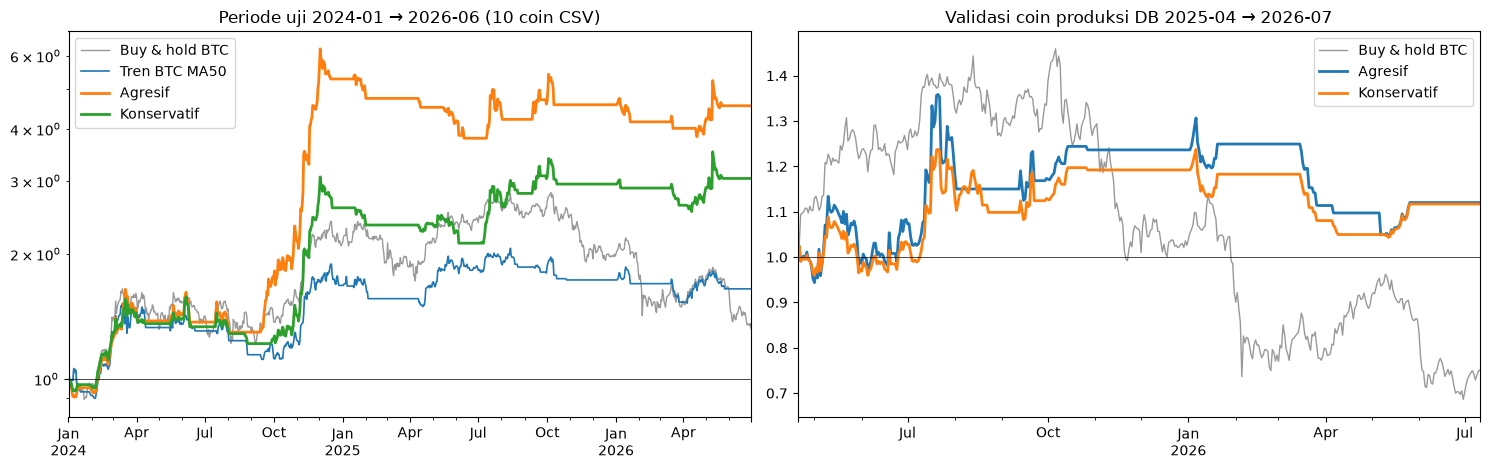

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
ax = axes[0]
_, e_btc = run(P, hold_btc, *TEST)
_, e_ma = run(P, bc_ma50, *TEST)
e_btc.plot(ax=ax, color="#999999", lw=1, label="Buy & hold BTC")
e_ma.plot(ax=ax, lw=1.2, label="Tren BTC MA50")
for name, e in eq_test.items():
    e.plot(ax=ax, lw=2, label=name)
ax.set_yscale("log"); ax.axhline(1, color="black", lw=0.5)
ax.set_title("Periode uji 2024-01 → 2026-06 (10 coin CSV)"); ax.legend()
ax = axes[1]
eq_val["Buy & hold BTC"].plot(ax=ax, color="#999999", lw=1, label="Buy & hold BTC")
for name in CFG:
    eq_val[name].plot(ax=ax, lw=2, label=name)
ax.axhline(1, color="black", lw=0.5)
ax.set_title("Validasi coin produksi DB 2025-04 → 2026-07"); ax.legend()
plt.tight_layout(); plt.show()

## Kesimpulan

### Strategi terpilih: **Tren + Momentum Rotasi** (F2) dengan ukuran posisi berbasis volatilitas + circuit breaker

| Strategi (periode uji 2024-01 → 2026-06) | Return | Max drawdown | Sharpe |
|---|---|---|---|
| **Konservatif** (tv 2%) | **+204%** | **−30.8%** | 1.37 |
| Agresif (tv 3%) | +355% | −39.1% | 1.49 |
| Tren BTC MA50 saja (F1) | +65% | −26.7% | 0.77 |
| Buy & hold BTC | +32% | −53.0% | 0.47 |
| V5 1 posisi (notebook 06, baseline) | −21% | −39.2% | – |

### Kenapa bisa dipercaya (lebih dari V5)
1. **Parameter dipilih hanya dari data 2021–2023**; hasil uji 2024–2026 tidak dipakai memilih.
2. **Bukan kebetulan satu kombinasi**: dari 144 kombinasi parameter, **97%** Sharpe-nya mengalahkan BTC
   dan **99%** untung di periode uji.
3. **Melindungi modal di pasar turun** — inti dari spesifikasi:
   2022 (BTC −65%) → Konservatif −12%; 2026 s/d Juni (BTC −34%) → +3%.
4. **Validasi di coin produksi DB** (22 coin Large/Mid, beda dari 10 coin CSV), periode BTC turun −25%:
   Konservatif **+11.7%, drawdown −15.7%** (BTC −24.9% / −53%).
5. Circuit breaker terbukti penting: tanpa itu, validasi DB hanya +4.1% dengan drawdown −23%.

### Yang harus diwaspadai (jujur)
- **Ketergantungan pada SUI** di data CSV: tanpa SUI, return uji Konservatif turun dari +204% ke **+5%**
  (Agresif +355% → +47%). SUI masuk daftar 10 coin karena sekarang sudah besar (*survivorship bias*),
  jadi angka +204% **terlalu optimis**. Angka yang lebih realistis adalah hasil validasi DB (+11.7%).
- **Win rate hanya ~40%**: banyak rugi kecil, sedikit untung besar (ciri strategi tren). Butuh disiplin
  bot — cocok dengan tujuan sistem otonom, tapi jangan dinilai dari beberapa trade pertama.
- **Sensitif biaya** untuk versi Konservatif: biaya 2× (0.3%/sisi) → +92%. Pastikan fee exchange rendah.
- Periode validasi DB pendek (15 bulan, 68 trade) — belum cukup untuk memastikan edge jangka panjang.

### Aturan final (Konservatif) — siap diimplementasikan
Dicek sekali sehari setelah candle harian close, eksekusi di open berikutnya:

1. **Rezim pasar**: kalau close BTC ≤ SMA50 BTC → **target = cash** (jual posisi kalau ada).
2. **Kandidat**: coin dengan close > SMA50 coin itu sendiri **dan** return 14 hari > 0.
3. **Skor** = return 14 hari ÷ standar deviasi return harian 14 hari → pilih **skor tertinggi** (1 coin).
4. **Rotasi**: kalau coin terpilih ≠ coin yang dipegang → jual, beli coin terpilih.
5. **Ukuran posisi** = min(100%, 2% ÷ volatilitas harian 20 hari coin) dari modal; sisanya tetap cash.
6. **Circuit breaker**: equity turun ≥ 15% dari puncak → jual semua, **tidak entry 30 hari**, puncak di-reset.
7. **Tanpa hard stop per trade** (terbukti merugikan: −8%/−12% menurunkan hasil).

Rata-rata holding **~3.3 hari**, ~1 trade per minggu — sesuai target holding 3–7 hari di spesifikasi.

### Langkah berikutnya
1. Uji ulang dengan universe lebih besar & tanpa survivorship bias: download histori Binance Vision untuk
   semua coin Large/Mid di `flex_params` (bukan hanya 10 coin), jalankan notebook ini lagi.
2. Paper trading / Binance Testnet (`demo_balance`) minimal 1–3 bulan, bandingkan dengan backtest.
3. Baru setelah itu implementasi ke backend (endpoint sinyal rotasi + circuit breaker di Rust).